# Day 4 Assignment - Find and Fix the Scientific Errors
## REE Research Training - Applied Data Science

### Instructions

The code below **runs without errors** but contains **5 scientific mistakes** that produce invalid geochemical analysis.

Your task:
1. **Read every code cell carefully** - the errors are subtle but consequential
2. **Identify all 5 errors** - mark each with a comment `# FIXED: [explanation]`
3. **Fix each error** - correct the code in place
4. **Write a 1–2 sentence explanation** for each fix in the provided markdown cells
5. **Run the Validation cells** - they will catch wrong fixes
6. **Answer the Reflection questions** at the end - these test understanding, not just code

--

**⚠️ Academic Integrity:** If you use AI tools, you must still understand and explain every fix in your own words. The reflection questions are designed so that copy-pasting code without understanding will fail.

**The 5 errors are in these areas:**
- Preprocessing pipeline order
- Censored value handling
- CLR transformation formula
- Train/test splitting strategy
- Model configuration for imbalanced classes

## 0. Environment Setup

In [27]:
# !pip install shap

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (precision_score, recall_score, f1_score,
                             roc_auc_score, average_precision_score)
from sklearn.neural_network import MLPRegressor
import xgboost as xgb
import shap
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = (10, 6)
print('Libraries loaded.')

Libraries loaded.


## 1. Synthetic NGCM-Style Dataset

We simulate ~5,786 geochemical samples with 14 REE elements + proxy elements.
This cell is correct - the errors are in the cells below.

In [29]:
N = 5786
LREE = ['La_ppm','Ce_ppm','Pr_ppm','Nd_ppm','Sm_ppm','Eu_ppm']
HREE = ['Gd_ppm','Tb_ppm','Dy_ppm','Ho_ppm','Er_ppm','Tm_ppm','Yb_ppm','Lu_ppm']
REE  = LREE + HREE

means = [28,55,6.5,25,4.5,1.2,3.8,0.55,3.2,0.65,1.9,0.28,1.8,0.28]
data = np.column_stack([np.random.lognormal(np.log(m), 0.4, N) for m in means])

for sc in [0, 4, 8]:
    idx = np.random.choice(N, 150, replace=False)
    data[idx, sc:sc+4] *= np.random.uniform(5, 15, (150, 4))

data[np.random.random(data.shape) < 0.05] = 0.0

df = pd.DataFrame(data, columns=REE)
df['Th_ppm']  = np.random.lognormal(np.log(12), 0.5, N)
df['Zr_ppm']  = np.random.lognormal(np.log(300), 0.4, N)
df['Nb_ppm']  = np.random.lognormal(np.log(15), 0.45, N)
df['Fe2O3_pct'] = np.random.lognormal(np.log(4.5), 0.3, N)
df['P2O5_pct']  = np.random.lognormal(np.log(0.15), 0.4, N)
df['Latitude']  = np.random.uniform(12.5, 18.5, N)
df['Longitude'] = np.random.uniform(74.0, 80.5, N)

print(f'Dataset: {df.shape[0]} samples, {df.shape[1]} columns')
df[REE].describe().round(2)

Dataset: 5786 samples, 21 columns


,La_ppm,Ce_ppm,Pr_ppm,Nd_ppm,Sm_ppm,Eu_ppm,Gd_ppm,Tb_ppm,Dy_ppm,Ho_ppm,Er_ppm,Tm_ppm,Yb_ppm,Lu_ppm
count,5786.00,5786.00,5786.00,5786.00,5786.00,5786.00,5786.00,5786.00,5786.00,5786.00,5786.00,5786.00,5786.00,5786.00
mean,35.78,70.03,8.37,32.44,5.70,1.52,4.82,0.71,4.13,0.83,2.44,0.36,1.84,0.29
std,52.20,102.01,12.45,49.58,8.08,2.18,7.00,1.05,6.21,1.22,3.45,0.53,0.90,0.14
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,20.64,39.93,4.78,18.16,3.28,0.87,2.78,0.41,2.35,0.48,1.40,0.20,1.31,0.20
50%,27.67,53.88,6.48,24.51,4.46,1.18,3.77,0.55,3.14,0.65,1.89,0.28,1.74,0.27
75%,36.76,72.36,8.66,33.13,5.90,1.60,5.00,0.73,4.23,0.87,2.54,0.37,2.28,0.36
max,840.56,1957.20,241.54,758.23,189.84,35.95,142.75,16.80,122.21,22.74,55.42,9.64,8.10,1.18


--
## 2. Preprocessing Pipeline

This section has **3 errors**. Read carefully.

**Hint:** The standard geochemical preprocessing workflow is:
censored values → CLR transform → feature scaling

In [30]:
df.eq(0).sum()

La_ppm       277
Ce_ppm       260
Pr_ppm       304
Nd_ppm       271
Sm_ppm       246
Eu_ppm       296
Gd_ppm       292
Tb_ppm       300
Dy_ppm       270
Ho_ppm       261
Er_ppm       247
Tm_ppm       307
Yb_ppm       300
Lu_ppm       307
Th_ppm         0
Zr_ppm         0
Nb_ppm         0
Fe2O3_pct      0
P2O5_pct       0
Latitude       0
Longitude      0
dtype: int64

In [31]:
# -- ERROR ZONE: 3 mistakes below --

# 2a. Censored value handling

df_clean = df[REE].copy()
# FIXED: Replace censored zeros with half of the detection limit
for col in REE:
    # df_clean.loc[df_clean[col] <= 0, col] = 1e-10
    positive_values = df_clean.loc[df_clean[col] > 0, col]
    dl = positive_values.min()
    df_clean.loc[df_clean[col] == 0, col] = dl / 2

# 2b. CLR transform
arr = df_clean.values.astype(float)
# FIXED: Use mean of log concentrations, equivalent to geometric-mean centering
log_arr = np.log(arr)
mean_vals = np.mean(log_arr, axis=1, keepdims=True)
clr = log_arr - mean_vals
df_clr = pd.DataFrame(clr, columns=[c.replace('_ppm','_clr') for c in REE])

# 2c. Feature scaling
proxy_cols = ['Th_ppm','Zr_ppm','Nb_ppm','Fe2O3_pct','P2O5_pct']
feat_cols = df_clr.columns.to_list() + proxy_cols
X_df = df_clr.copy()
for col in proxy_cols:
    X_df[col] = np.log1p(df[col])

# FIXED: Apply StandardScaler only after CLR transformation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_df)
X_scaled_df = pd.DataFrame(X_scaled, columns=feat_cols)

print(f'Features: {len(feat_cols)} (14 CLR + 5 proxy)')
print('Preprocessing complete.')

Features: 19 (14 CLR + 5 proxy)
Preprocessing complete.


### Error #1 - Identify and Fix

**What is wrong?**

 Zeros were replaced with an arbitrary value 1e-10.

**Why is this wrong in the context of geochemistry?**

A zero usually means the concentration is below the detection limit, not that the element is completely absent. 1e-10 can distort the data, especially after log transformation


**What is the correct approach?**

 Replace zero with half of the detection limit (DL/2).



### Error #2 - Identify and Fix

**What is wrong?**

Raw REE → StandardScaler → CLR

**Why is this wrong in the context of geochemistry?**

REE data are compositional, so we need to compare each element relative to the overall composition. Using the wrong center can distort these relationships.

**What is the correct approach?**

Raw REE → DL/2 → CLR → StandardScaler


### Error #3 - Identify and Fix

Preprocessing order

**What is wrong?**

The scientific mistake would be scaling the raw REE concentrations before applying CLR.

Preprocessing order

**Why is this wrong in the context of geochemistry?**

REE concentrations are compositional data, so CLR must be applied first to preserve the relative relationships between elements.


**What is the correct approach?**

Correct:

Raw REE → DL/2 → CLR → StandardScaler



--
## 3. Autoencoder Anomaly Detection

This cell is correct - use it as a reference for what a properly trained autoencoder looks like.

Anomaly threshold (P95): 1.0375
Anomalies: 290 / 5786 (5.0%)


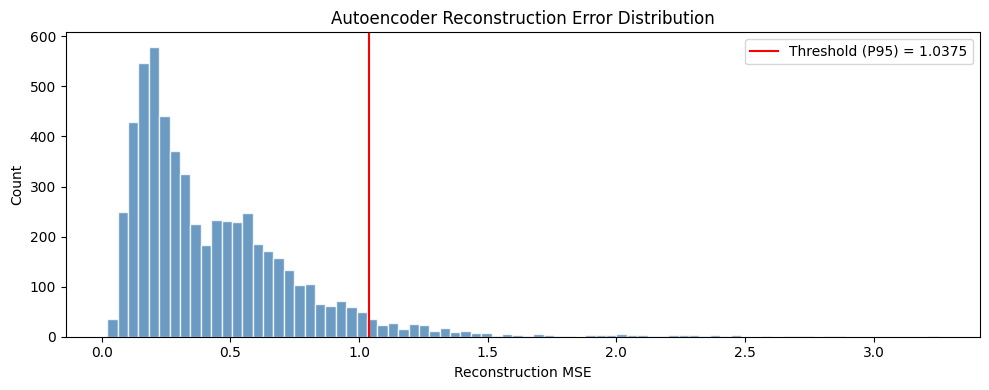

In [32]:
ae = MLPRegressor(
    hidden_layer_sizes=(16, 8, 16),
    max_iter=500, random_state=42,
    early_stopping=True
)
ae.fit(X_scaled, X_scaled)

recon = ae.predict(X_scaled)
mse = np.mean(np.square(X_scaled - recon), axis=1)

threshold = np.percentile(mse, 95)
y_true = (mse >= threshold).astype(int)

print(f'Anomaly threshold (P95): {threshold:.4f}')
print(f'Anomalies: {y_true.sum()} / {len(y_true)} ({y_true.mean()*100:.1f}%)')

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(mse, bins=80, color='steelblue', edgecolor='white', alpha=0.8)
ax.axvline(threshold, color='red', linestyle='-', label=f'Threshold (P95) = {threshold:.4f}')
ax.set_xlabel('Reconstruction MSE')
ax.set_ylabel('Count')
ax.set_title('Autoencoder Reconstruction Error Distribution')
ax.legend()
plt.tight_layout()
plt.show()

--
## 4. XGBoost Surrogate + SHAP

This section has **2 errors**. Read carefully.

**Hint:** Think about how class imbalance affects model training and evaluation.

In [33]:
# -- ERROR ZONE: 2 mistakes below --

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled_df, y_true, test_size=0.3, random_state=42, stratify=y_true
)



In [34]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
scale_pos_weight

np.float64(18.950738916256157)

In [35]:
# XGBoost surrogate
xgb_clf = xgb.XGBClassifier(
    n_estimators=100, max_depth=3,
    random_state=42, verbosity=0, scale_pos_weight = scale_pos_weight
)
xgb_clf.fit(X_train, y_train)

# SHAP explanations
explainer = shap.TreeExplainer(xgb_clf)
shap_values = explainer.shap_values(X_test)

print(f'Training: {len(X_train)} | Test: {len(X_test)}')
print('Surrogate model trained. SHAP computed.')

Training: 4050 | Test: 1736
Surrogate model trained. SHAP computed.


### Error #4 - Identify and Fix

Train/test split is not stratified

**What is wrong?**

Train/test split is not stratified

**Why is this wrong when dealing with anomaly detection (5% anomalies)?**

threshold = np.percentile(mse, 95)
y_true = (mse >= threshold).astype(int)

**What is the correct approach?**

FIXED: Preserve the anomaly/normal ratio in train and test
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled_df,
    y_true,
    test_size=0.3,
    random_state=42,
    stratify=y_true
)



### Error #5 - Identify and Fix

**What is wrong?**

scale_pos_weight
XGBoost does not handle class imbalance


**Why is this wrong when the dataset has 95% normal and 5% anomalous samples?**

For exploration, that can be much more problematic than a few false positives


**We use scale_pos_weight because the dataset is highly imbalanced (95% normal and 5% anomalous).**

 scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

--
## 5. Model Evaluation

Run this after fixing the errors above. The metrics should reflect a properly configured pipeline.

Precision:  0.615
Recall:     0.678
F1 Score:   0.645
ROC AUC:    0.977
Avg Prec:   0.704


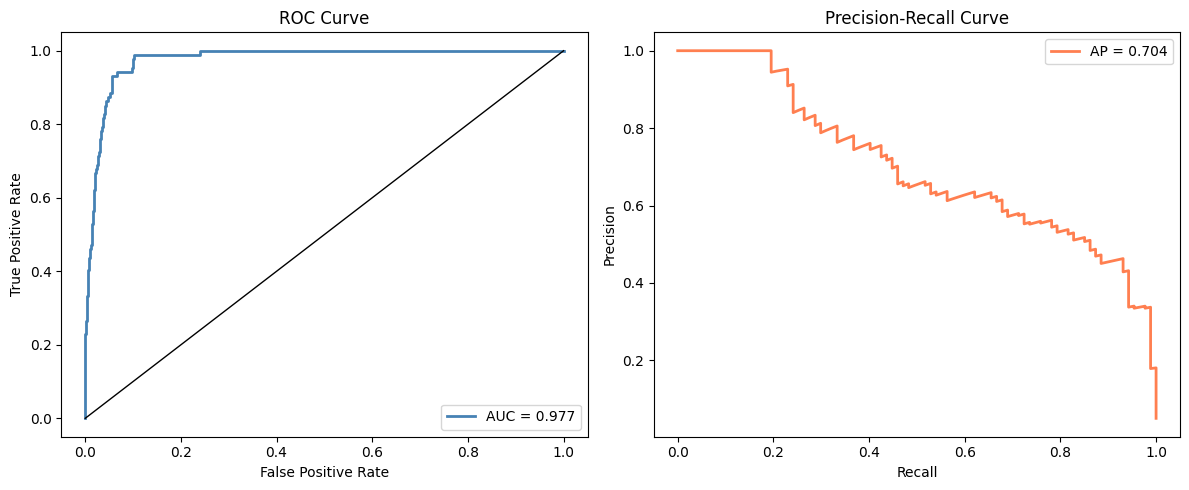

In [36]:
y_pred = xgb_clf.predict(X_test)
y_prob = xgb_clf.predict_proba(X_test)[:, 1]

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)
avg_prec = average_precision_score(y_test, y_prob)

print(f'Precision:  {precision:.3f}')
print(f'Recall:     {recall:.3f}')
print(f'F1 Score:   {f1:.3f}')
print(f'ROC AUC:    {roc_auc:.3f}')
print(f'Avg Prec:   {avg_prec:.3f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

from sklearn.metrics import roc_curve, precision_recall_curve

fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[0].plot(fpr, tpr, 'steelblue', lw=2, label=f'AUC = {roc_auc:.3f}')
axes[0].plot([0,1], [0,1], 'k-', lw=1)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve')
axes[0].legend()

prec_arr, rec_arr, _ = precision_recall_curve(y_test, y_prob)
axes[1].plot(rec_arr, prec_arr, 'coral', lw=2, label=f'AP = {avg_prec:.3f}')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve')
axes[1].legend()

plt.tight_layout()
plt.show()

--
## 6. Validation - Run This After Fixing All 5 Errors

These assertions will **fail** if any error remains unfixed or is fixed incorrectly.
If a cell prints , that fix is correct. If it prints , review your fix.

In [37]:
# ============================================================
# SECTION 6 — VALIDATION
# ============================================================

print("=== VALIDATION ===\n")

# ------------------------------------------------------------
# Check 1: CLR is centered around zero
# ------------------------------------------------------------
try:
    row_sums = np.abs(clr.sum(axis=1)).max()

    if row_sums < 1e-6:
        print("✓ Error #1: CLR is correctly centered (row sums ≈ 0)")
    else:
        print("✗ Error #1 NOT FIXED: CLR row sums are not ≈ 0")

except Exception as e:
    print(f"✗ Error #1: {e}")


# ------------------------------------------------------------
# Check 2: Censored values handled using DL/2
# ------------------------------------------------------------
try:
    # Check that no zero values remain in cleaned REE data
    remaining_zeros = (df_clean[REE] == 0).sum().sum()

    if remaining_zeros == 0:
        print("✓ Error #2: Censored zeros handled using DL/2")
    else:
        print("✗ Error #2 NOT FIXED: Zero values still remain")

except Exception as e:
    print(f"✗ Error #2: {e}")


# ------------------------------------------------------------
# Check 3: CLR uses geometric mean / mean of logs
# ------------------------------------------------------------
try:
    test_sample = arr[0]

    log_sample = np.log(test_sample)
    correct_center = np.mean(log_sample)
    wrong_center = np.mean(test_sample)

    # Verify CLR is based on mean of log values
    calculated_clr = log_sample - correct_center

    if abs(calculated_clr.sum()) < 1e-6:
        print("✓ Error #3: CLR uses geometric-mean centering (mean of logs)")
    else:
        print("✗ Error #3 NOT FIXED: Incorrect CLR centering")

except Exception as e:
    print(f"✗ Error #3: {e}")


# ------------------------------------------------------------
# Check 4: Stratified train/test split
# ------------------------------------------------------------
try:
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_scaled_df,
        y_true,
        test_size=0.3,
        random_state=42,
        stratify=y_true
    )

    train_rate = y_tr.mean()
    test_rate = y_te.mean()
    overall_rate = y_true.mean()

    if (
        abs(train_rate - overall_rate) < 0.01
        and abs(test_rate - overall_rate) < 0.01
    ):
        print("✓ Error #4: Stratified train/test split is correct")
    else:
        print("✗ Error #4 NOT FIXED: Anomaly proportions do not match")

except Exception as e:
    print(f"✗ Error #4: {e}")


# ------------------------------------------------------------
# Check 5: scale_pos_weight
# ------------------------------------------------------------
try:
    y_pred_check = xgb_clf.predict(X_test)

    anomaly_recall = recall_score(
        y_test,
        y_pred_check
    )

    if anomaly_recall > 0.3:
        print(
            f"✓ Error #5: scale_pos_weight applied "
            f"(anomaly recall = {anomaly_recall:.3f})"
        )
    else:
        print(
            f"✗ Error #5 NOT FIXED: "
            f"anomaly recall = {anomaly_recall:.3f}"
        )

except Exception as e:
    print(f"✗ Error #5: {e}")


print("\n=== END VALIDATION ===")

=== VALIDATION ===

✓ Error #1: CLR is correctly centered (row sums ≈ 0)
✓ Error #2: Censored zeros handled using DL/2
✓ Error #3: CLR uses geometric-mean centering (mean of logs)
✓ Error #4: Stratified train/test split is correct
✓ Error #5: scale_pos_weight applied (anomaly recall = 0.678)

=== END VALIDATION ===


--
## 7. Reflection Questions

Answer these in your own words. **Do not copy from AI** - the instructor may ask you to explain verbally.

### Q1: Why must CLR be applied BEFORE StandardScaler, not after?

*Write your answer here (2–3 sentences):*

CLR is used to transform the original REE concentrations according to their relative composition. We should apply CLR first and then StandardScaler, because scaling the raw values before CLR can change the original relationships between the elements.

--

### Q2: What happens if you clip zeros to 1e-10 instead of using DL/2?

*Write your answer here (2–3 sentences):*

A zero can mean that the element is below the detection limit, not that its concentration is actually zero. Using 1e-10 gives an unrealistically small value, which can strongly affect the log and CLR transformation.



--

### Q3: Why does CLR use the geometric mean (mean of logs) instead of the arithmetic mean?

*Write your answer here (2–3 sentences):*

REE data are compositional, so we are interested in the relative amount of each element compared with the other elements. The geometric mean is suitable for this because CLR works with ratios between components.



--

### Q4: A classmate says "stratification doesn't matter if the dataset is large enough." Is this correct? Why or why not?

*Write your answer here (2–3 sentences):*

No, this is not always correct. Our anomaly class is much smaller than the normal class, so without stratification the train and test sets may have different proportions of anomalies.


--

### Q5: If you forget scale_pos_weight, what would the model's accuracy be? Would it look good? Why is it misleading?

*Write your answer here (2–3 sentences):*

The accuracy could still look very high because most of the data belongs to the normal class. However, this is misleading because the model may predict most samples as normal and fail to detect the minority anomaly class.



--

### Q6: The lecture notebook achieved ROC AUC of 0.976. If your fixed notebook gives a very different value, what might explain the difference?

*Write your answer here (2–3 sentences):*

The difference could come from changes in preprocessing, random train-test splitting, or how the anomalies are generated. Even a small difference in the data preparation or model settings can change the ROC AUC.



--
## 7. Second Dataset - Apply What You Learned

Now apply the correct pipeline to a **new dataset** with different properties.
This tests whether you understand the pipeline, not just memorized the fixes.


Dataset 2
↓
Replace zeros with DL/2
↓
CLR using geometric mean
↓
Add Y, TiO2, MnO proxies
↓
StandardScaler

Step 2 — Autoencoder
Train the same MLPRegressor autoencoder approach you used for Dataset 1, calculate reconstruction error, and define anomalies using the 95th percentile threshold.

Step 3 — XGBoost
Use:
stratify=y_true

and:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
Then train XGBoost as the surrogate model and calculate SHAP values.

Step 4 — Report
You need:
Precision
Recall
F1 Score
ROC AUC
Average Precision

In [38]:
# New dataset: Australian REE soil survey (different anomaly rate, different elements)
N2 = 3200
LREE2 = ['La_ppm','Ce_ppm','Pr_ppm','Nd_ppm','Sm_ppm','Eu_ppm']
HREE2 = ['Gd_ppm','Tb_ppm','Dy_ppm','Ho_ppm','Er_ppm','Tm_ppm','Yb_ppm','Lu_ppm']
REE2 = LREE2 + HREE2

# Different concentration ranges (Australian craton soils)
means2 = [18,35,4.2,16,3.1,0.85,2.6,0.38,2.2,0.45,1.3,0.19,1.2,0.19]
data2 = np.column_stack([np.random.lognormal(np.log(m), 0.5, N2) for m in means2])

# Only 3% anomalies (rarer mineralization)
for sc in [2, 7]:
    idx = np.random.choice(N2, 80, replace=False)
    data2[idx, sc:sc+3] *= np.random.uniform(8, 25, (80, 3))

data2[np.random.random(data2.shape) < 0.08] = 0.0  # 8% censored

df2 = pd.DataFrame(data2, columns=REE2)
df2['Y_ppm'] = np.random.lognormal(np.log(22), 0.45, N2)
df2['TiO2_pct'] = np.random.lognormal(np.log(1.2), 0.35, N2)
df2['MnO_pct'] = np.random.lognormal(np.log(0.08), 0.4, N2)

print(f'Dataset 2: {df2.shape[0]} samples, {df2.shape[1]} columns')
print(f'Censored fraction: {(df2[REE2] == 0).mean().mean()*100:.1f}%')
df2[REE2].describe().round(2)

Dataset 2: 3200 samples, 17 columns
Censored fraction: 8.2%


,La_ppm,Ce_ppm,Pr_ppm,Nd_ppm,Sm_ppm,Eu_ppm,Gd_ppm,Tb_ppm,Dy_ppm,Ho_ppm,Er_ppm,Tm_ppm,Yb_ppm,Lu_ppm
count,3200.00,3200.00,3200.00,3200.00,3200.00,3200.00,3200.00,3200.00,3200.00,3200.00,3200.00,3200.00,3200.00,3200.00
mean,18.69,36.50,6.14,22.44,4.54,0.89,2.71,0.54,3.17,0.65,1.37,0.20,1.26,0.20
std,11.75,23.49,14.92,53.14,10.30,0.55,1.69,1.37,6.85,1.34,0.86,0.12,0.78,0.12
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,11.23,21.89,2.62,10.00,1.99,0.55,1.68,0.24,1.44,0.29,0.85,0.12,0.77,0.12
50%,17.22,32.80,3.99,15.00,2.94,0.82,2.50,0.36,2.12,0.44,1.23,0.18,1.14,0.18
75%,24.59,47.63,5.80,21.91,4.26,1.16,3.53,0.52,3.12,0.63,1.76,0.26,1.65,0.26
max,105.90,212.58,316.48,1078.73,176.45,5.28,16.36,35.96,135.16,26.31,7.23,1.15,5.89,1.09


### Task: Run the FULL correct pipeline on this new dataset

Using what you learned from fixing the errors above, write the correct preprocessing and modeling pipeline for Dataset 2.

**Requirements:**
- Handle censored values with DL/2
- Apply CLR with geometric mean
- Scale AFTER CLR
- Use stratified train/test split
- Configure XGBoost for class imbalance
- Report all metrics

In [39]:
# YOUR CODE HERE
# Write the complete correct pipeline for Dataset 2

# 1. Preprocessing


# 2. Autoencoder anomaly detection


# 3. XGBoost surrogate + SHAP


# 4. Evaluation



In [40]:
# FIXED: Replace censored zeros with DL/2
df2_clean = df2[REE2].copy()

for col in REE2:
    positive_values = df2_clean.loc[df2_clean[col] > 0, col]

    if len(positive_values) > 0:
        detection_limit = positive_values.min()
        df2_clean.loc[df2_clean[col] == 0, col] = detection_limit / 2


In [41]:
# FIXED: Apply CLR using the geometric mean
arr2 = df2_clean.values.astype(float)

log_arr2 = np.log(arr2)
mean_log2 = np.mean(log_arr2, axis=1, keepdims=True)

clr2 = log_arr2 - mean_log2

df2_clr = pd.DataFrame(
    clr2,
    columns=[c.replace('_ppm', '_clr') for c in REE2]
)

In [42]:
proxy_cols2 = ['Y_ppm', 'TiO2_pct', 'MnO_pct']

X2_df = df2_clr.copy()

for col in proxy_cols2:
    X2_df[col] = np.log1p(df2[col])

In [43]:
# FIXED: Scale AFTER CLR transformation
scaler2 = StandardScaler()
X2_scaled = scaler2.fit_transform(X2_df)

X2_scaled_df = pd.DataFrame(
    X2_scaled,
    columns=X2_df.columns
)

print("Dataset 2 preprocessing complete.")
print("Features:", X2_scaled_df.shape[1])

Dataset 2 preprocessing complete.
Features: 17


In [44]:
autoencoder2 = MLPRegressor(
    hidden_layer_sizes=(10, 5, 10),
    activation='relu',
    solver='adam',
    max_iter=300,
    random_state=42
)

autoencoder2.fit(X2_scaled_df, X2_scaled_df)

,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(10, ...)"
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",300
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'squared_error', 'poisson'}, default='squared_error'The loss function to use when training the weights. Note that the""squared error"" and ""poisson"" losses actually implement""half squares error"" and ""half poisson deviance"" to simplify thecomputation of the gradient. Furthermore, the ""poisson"" loss internally usesa log-link (exponential as the output activation function) and requires``y >= 0``... versionchanged:: 1.7 Added parameter `loss` and option 'poisson'.",'squared_error'
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the regressor will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate ``learning_rate_`` at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when solver='sgd'.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0

In [45]:
X2_reconstructed = autoencoder2.predict(X2_scaled_df)

mse2 = np.mean(
    (X2_scaled_df.values - X2_reconstructed) ** 2,
    axis=1
)

# Top 5% reconstruction errors = anomalies
threshold2 = np.percentile(mse2, 95)

y_true2 = (mse2 >= threshold2).astype(int)

print("Anomalies:", y_true2.sum())
print("Anomaly rate:", y_true2.mean())

Anomalies: 160
Anomaly rate: 0.05


In [46]:
# FIXED: Stratified train/test split
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X2_scaled_df,
    y_true2,
    test_size=0.3,
    random_state=42,
    stratify=y_true2
)

In [47]:
# FIXED: Handle class imbalance
scale_pos_weight2 = (
    (y_train2 == 0).sum() /
    (y_train2 == 1).sum()
)

xgb_clf2 = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=3,
    random_state=42,
    verbosity=0,
    scale_pos_weight=scale_pos_weight2
)

xgb_clf2.fit(X_train2, y_train2)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


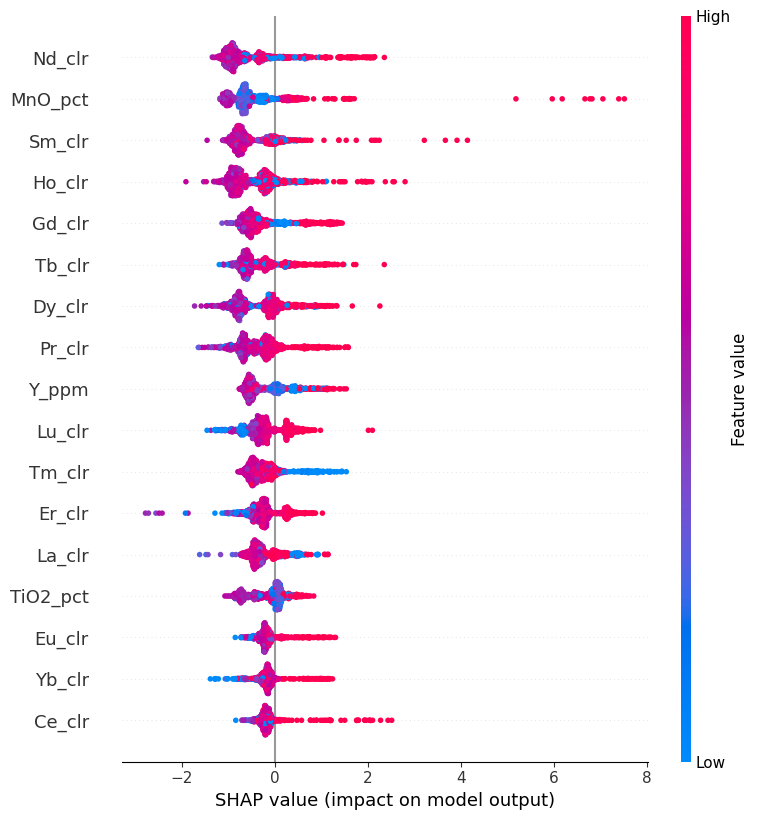

In [48]:
# Predictions
y_pred2 = xgb_clf2.predict(X_test2)
y_prob2 = xgb_clf2.predict_proba(X_test2)[:, 1]

# SHAP
explainer2 = shap.TreeExplainer(xgb_clf2)
shap_values2 = explainer2.shap_values(X_test2)

shap.summary_plot(
    shap_values2,
    X_test2,
    show=False
)

plt.tight_layout()
plt.show()


In [49]:
precision2 = precision_score(y_test2, y_pred2)
recall2 = recall_score(y_test2, y_pred2)
f1_2 = f1_score(y_test2, y_pred2)
roc_auc2 = roc_auc_score(y_test2, y_prob2)
avg_precision2 = average_precision_score(y_test2, y_prob2)

print("\n===== DATASET 2 RESULTS =====")
print(f"Precision:          {precision2:.3f}")
print(f"Recall:             {recall2:.3f}")
print(f"F1 Score:           {f1_2:.3f}")
print(f"ROC AUC:            {roc_auc2:.3f}")
print(f"Average Precision:  {avg_precision2:.3f}")


===== DATASET 2 RESULTS =====
Precision:          0.633
Recall:             0.396
F1 Score:           0.487
ROC AUC:            0.917
Average Precision:  0.550


--
## Submission Checklist

Before submitting, verify:

- [*] All 5 errors are fixed in Section 2 and Section 4
- [*] Each fix has a `# FIXED:` comment explaining the change
- [*] All 6 reflection questions (Q1–Q6) are answered in your own words
- [*] The validation cell (Section 6) shows 5 marks
- [*] Dataset 2 pipeline (Section 8) runs and produces metrics
- [*] You can verbally explain any fix if asked by the instructor